# Small Data Modelling & Evaluating
---

## Objectives
- Train the same CNN model from the full dataset, but with a smaller subset (10% of the dataset)
- Answer part of **Business Requirement 2**: identifying animal species in images, while showing the effect of dataset size.
- Validate hypothesis 2: 
    - Training the model on a smaller dataset reduces model performance and accuracy.

## Inputs
- inputs/datasets/animals/small-data/train/
- inputs/datasets/animals/image/validation/
- inputs/datasets/animals/image/test/
- Image shape embeddings: outputs/v1/image_shape.pkl

## Outputs
- Image distribution plots for small data training, validation, and testing.
- Image augmentation pipeline.
- ML learning curves for both runs.
- Comparison table (subset vs full dataset).
- Model evaluation stored in pickle file.
- Predictions on random test images.

## Additional Comments | Insights | Conclusions
- Highlights the importance of dataset size in CNN performance
- The more diverse training images the model sees, the better it can capture subtle differences between species.

---

### Import libraries
A full import list for Notebook 04

In [1]:
# Core Python & utilities
import os
import random
import joblib
import numpy as np
import pandas as pd
import shutil

# Plotting & Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.image import imread

# Machine Learning / Deep Learning
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Metrics
from sklearn.metrics import classification_report, confusion_matrix

# Style for plots
sns.set_style("white")


2025-09-28 21:40:30.969458: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-28 21:40:30.993427: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-28 21:40:32.793494: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-28 21:40:37.599045: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

## Set working directory

In [2]:
cwd = os.getcwd()
os.chdir('/workspaces/Animal_detection_camera')
print("You set a new current directory")

work_dir = os.getcwd()
work_dir

You set a new current directory


'/workspaces/Animal_detection_camera'

## Set output directory

In [3]:
version = 'v1'
file_path = f'outputs/{version}/small-data'
os.makedirs(file_path, exist_ok=True)
img_path = f'app_images/small-data'
os.makedirs(img_path, exist_ok=True)
print(f"Saving results to: {file_path}")
print(f"Saving images to: {img_path}")

Saving results to: outputs/v1/small-data
Saving images to: app_images/small-data


---

# Number of images in train, test and validation data
---

## Define Small Subset Creation Function


In [4]:
def create_subset(original_dir, subset_dir, fraction=0.1):
    os.makedirs(subset_dir, exist_ok=True)
    for class_name in os.listdir(original_dir):
        class_path = os.path.join(original_dir, class_name)
        if not os.path.isdir(class_path):
            continue
        subset_class_path = os.path.join(subset_dir, class_name)
        os.makedirs(subset_class_path, exist_ok=True)

        files = os.listdir(class_path)
        sample_size = max(1, int(len(files) * fraction))
        sampled_files = random.sample(files, sample_size)

        for f in sampled_files:
            shutil.copy(os.path.join(class_path, f), os.path.join(subset_class_path, f))


### Create 10% small-data subset

In [5]:
small_data_dir = "inputs/datasets/animals/small-data/train"
if not os.path.exists(small_data_dir):
    print("Creating small-data subset...")
    create_subset("inputs/datasets/animals/image/train", small_data_dir, fraction=0.1)
else:
    print("Small-data subset already exists.")

Small-data subset already exists.


## Set input directories
Set train, validation and test paths

In [6]:
my_data_dir = "inputs/datasets/animals"
train_path = small_data_dir
val_path = "inputs/datasets/animals/image/validation"
test_path = "inputs/datasets/animals/image/test"

## Set Labels

In [7]:
labels = os.listdir("inputs/datasets/animals/image/train")
print(f"Project Labels: {labels}")

Project Labels: ['lemur', 'snake', 'elephant', 'frog', 'chimpanzee', 'chinchilla', 'flamingo', 'mongoose', 'ostrich', 'ferret', 'camel', 'bee', 'mole', 'penguin', 'leopard', 'hawk', 'hedgehog', 'walrus', 'falcon', 'grasshopper', 'beaver', 'antelope', 'giraffe', 'duck', 'lizard', 'crab', 'goose', 'gorilla', 'jaguar', 'sheep', 'lynx', 'butterfly', 'panda', 'goat', 'deer', 'peacock', 'dog', 'whale', 'kangaroo', 'seal', 'cheetah', 'cow', 'iguana', 'hippopotamus', 'fox', 'cat', 'donkey', 'raccoon', 'blackbird', 'buffalo', 'koala', 'crocodile', 'dolphin', 'hyena', 'porcupine', 'bear', 'squid', 'spider', 'eagle', 'bison', 'owl', 'otter', 'snail', 'wolf']


## Set Image Shape

In [8]:
image_shape = joblib.load(filename=f"outputs/{version}/image_shape.pkl")
image_shape = (128, 128, 3)
print("Using image shape:", image_shape)

Using image shape: (128, 128, 3)


## Data Generators 
Small vs Full Datasets

In [9]:
datagen = ImageDataGenerator(rescale=1./255)

train_small_gen = datagen.flow_from_directory(
    "inputs/datasets/animals/small-data/train",
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

train_full_gen = datagen.flow_from_directory(
    "inputs/datasets/animals/image/train",
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

val_gen = datagen.flow_from_directory(
    "inputs/datasets/animals/image/validation",
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)


Found 997 images belonging to 64 classes.


Found 10050 images belonging to 64 classes.
Found 1400 images belonging to 64 classes.


---

## Image Distribution Analysis
---

### Prepare Frequency Counter

In [10]:
data = {'Set': [], 'Label': [], 'Frequency': []}
folders = ['small-data/train', 'image/validation', 'image/test']

### Count Images Per Set Of Labels

In [11]:
for folder in folders:
    folder_path = os.path.join(my_data_dir, folder)
    set_name = folder.split('/')[-1]
    
    for label in labels:
        n = len(os.listdir(os.path.join(folder_path, label)))
        data['Set'].append(set_name)
        data['Label'].append(label)
        data['Frequency'].append(n)
        print(f"* {set_name} - {label}: {n} images")

* train - lemur: 15 images
* train - snake: 15 images
* train - elephant: 20 images
* train - frog: 21 images
* train - chimpanzee: 15 images
* train - chinchilla: 15 images
* train - flamingo: 15 images
* train - mongoose: 15 images
* train - ostrich: 15 images
* train - ferret: 15 images
* train - camel: 15 images
* train - bee: 15 images
* train - mole: 12 images
* train - penguin: 15 images
* train - leopard: 15 images
* train - hawk: 15 images
* train - hedgehog: 15 images
* train - walrus: 15 images
* train - falcon: 15 images
* train - grasshopper: 15 images
* train - beaver: 15 images
* train - antelope: 15 images
* train - giraffe: 15 images
* train - duck: 15 images
* train - lizard: 15 images
* train - crab: 15 images
* train - goose: 15 images
* train - gorilla: 15 images
* train - jaguar: 13 images
* train - sheep: 15 images
* train - lynx: 15 images
* train - butterfly: 15 images
* train - panda: 15 images
* train - goat: 15 images
* train - deer: 15 images
* train - peac

### Create Dataframe with Frequencies

In [12]:
df_freq_small = pd.DataFrame(data)
display(df_freq_small.head())

,Set,Label,Frequency
0,train,lemur,15
1,train,snake,15
2,train,elephant,20
3,train,frog,21
4,train,chimpanzee,15


### Plot Distribution Per Set

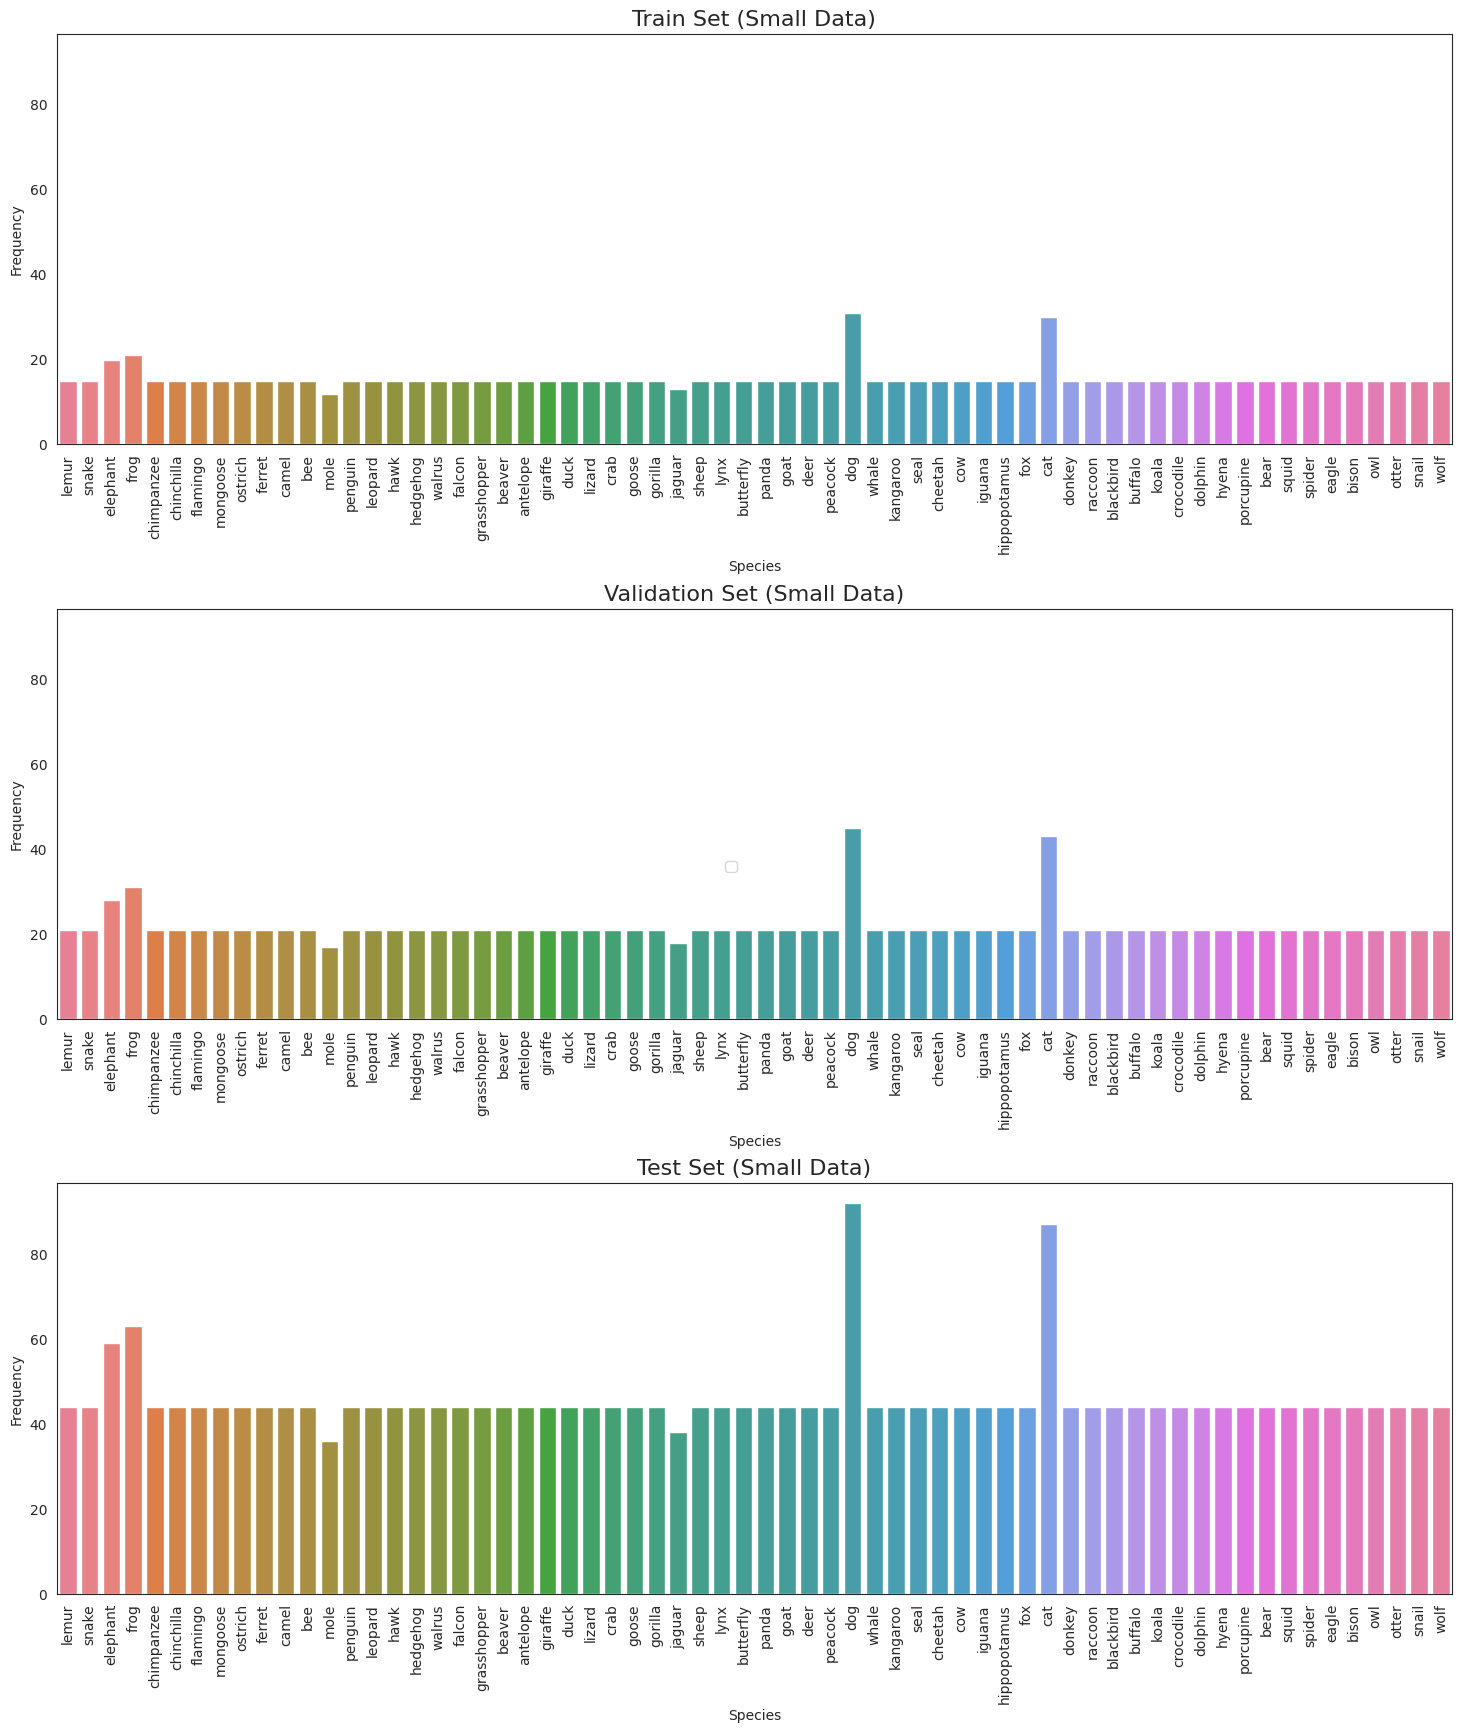

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(18, 20), sharey=True)
sets = ['train', 'validation', 'test']

for i, subset in enumerate(sets):
    sns.barplot(
        data=df_freq_small[df_freq_small['Set'] == subset],
        x='Label', y='Frequency',
        hue='Label', dodge=False, ax=axes[i]
    )
    axes[i].set_title(f"{subset.capitalize()} Set (Small Data)", fontsize=16)
    axes[i].set_xlabel("Species")
    axes[i].set_ylabel("Frequency")
    axes[i].tick_params(axis='x', rotation=90)

# Legend and layout
handles, labels_legend = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_legend, loc='center', ncol=6, fontsize=10)
plt.subplots_adjust(hspace=0.4, bottom=0.1)

### Save & Show Figure

In [14]:
fig.suptitle("Image Distribution per Set (Small Data)", fontsize=20)
plt.savefig(f'{img_path}/labels_distribution_rows_small.jpg',
            dpi=150, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

---

# Image Data augmentation
---

#### Initialize ImageDataGenerator and set batch size

In [15]:
batch_size = 16
train_datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.3,
    brightness_range=[0.7, 1.3],
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest',
    rescale=1./255
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

### Augment training image dataset

In [16]:
train_set = train_datagen.flow_from_directory(
    train_path,
    target_size=image_shape[:2],
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

Found 997 images belonging to 64 classes.


#### Augment validation image dataset

In [17]:
validation_set = val_test_datagen.flow_from_directory(
    val_path,
    target_size=image_shape[:2],
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 1400 images belonging to 64 classes.


#### Augment test image dataset

In [18]:
test_set = val_test_datagen.flow_from_directory(
    test_path,
    target_size=image_shape[:2],
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 2927 images belonging to 64 classes.


#### Save class indices

In [19]:
joblib.dump(value=train_set.class_indices,
    filename=f"{file_path}/small_class_indices.pkl")

['outputs/v1/small-data/small_class_indices.pkl']

## Preview Augmented Images

(16, 128, 128, 3)


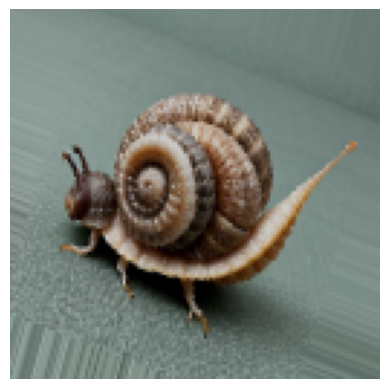

(16, 128, 128, 3)


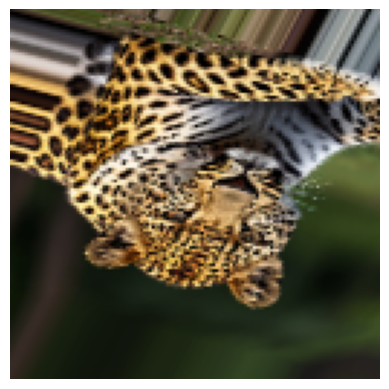

(16, 128, 128, 3)


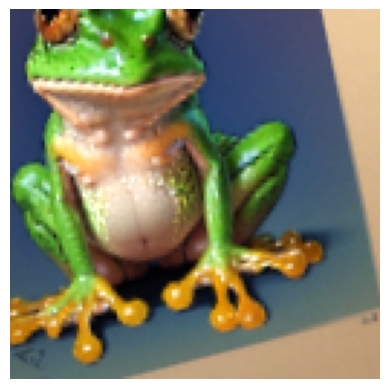

(16, 128, 128, 3)


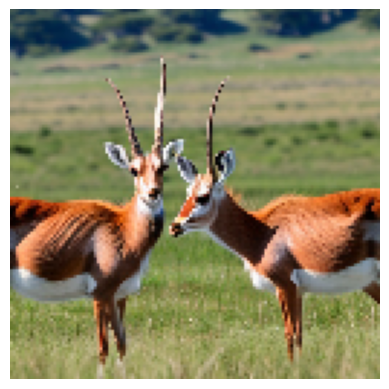

(16, 128, 128, 3)


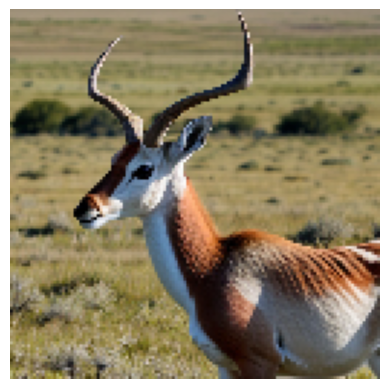

(16, 128, 128, 3)


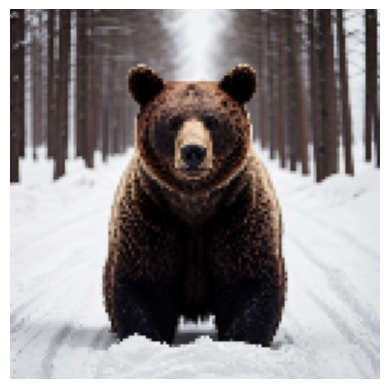

(16, 128, 128, 3)


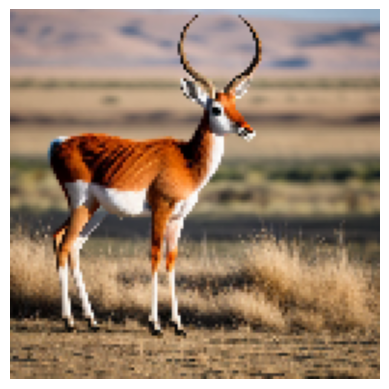

(16, 128, 128, 3)


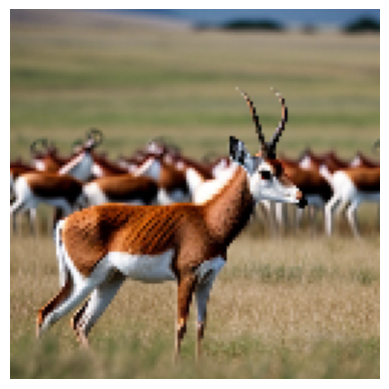

(16, 128, 128, 3)


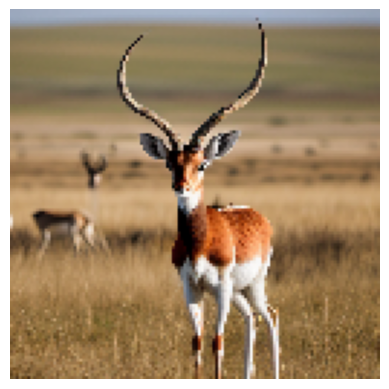

In [20]:
for _ in range(3):
    img, label = next(train_set)
    print(img.shape)
    plt.imshow(img[0])
    plt.axis("off")
    plt.show()

for _ in range(3):
    img, label = next(validation_set)
    print(img.shape)
    plt.imshow(img[0])
    plt.axis("off")
    plt.show()

for _ in range(3):
    img, label = next(test_set)
    print(img.shape)
    plt.imshow(img[0])
    plt.axis("off")
    plt.show()

Save class indices mapping

In [21]:
joblib.dump(value=train_set.class_indices,
            filename=f"{file_path}/small_class_indices.pkl")

['outputs/v1/small-data/small_class_indices.pkl']

---

# Model creation
---

## Small Data Model

In [22]:
def create_tf_model():
    # Load pretrained base model
    base_model = MobileNetV2(
        input_shape=image_shape,
        include_top=False,
        weights='imagenet'
    )

    # Freeze base layers
    base_model.trainable = False

    # Add custom classification layers on top
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(len(labels), activation='softmax')(x)

    # Build the model
    model = Model(inputs=base_model.input, outputs=outputs)

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


### Model Summary

In [23]:
create_tf_model().summary()

2025-09-28 21:40:51.833328: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,602,368 (9.93 MB)

 Trainable params: 344,384 (1.31 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Early Stopping 

In [24]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-6,
    verbose=1
)

ckpt = ModelCheckpoint(
    filepath=f"{file_path}/model_epoch{{epoch:02d}}-val_acc{{val_accuracy:.2f}}.weights.h5",
    save_weights_only=True,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

### Fit model for model training

In [25]:
model = create_tf_model()
history = model.fit(
    train_set,
    epochs=25,
    validation_data=validation_set,
    callbacks=[early_stop, reduce_lr, ckpt],
    verbose=1
)


/home/cistudent/.local/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 605ms/step - accuracy: 0.0838 - loss: 4.2979
Epoch 1: val_accuracy improved from None to 0.62643, saving model to outputs/v1/small-data/model_epoch01-val_acc0.63.weights.h5
63/63 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.1424 - loss: 3.8138 - val_accuracy: 0.6264 - val_loss: 2.2616 - learning_rate: 0.0010
Epoch 2/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 0.4518 - loss: 2.3606
Epoch 2: val_accuracy improved from 0.62643 to 0.85500, saving model to outputs/v1/small-data/model_epoch02-val_acc0.86.weights.h5
63/63 ━━━━━━━━━━━━━━━━━━━━ 47s 751ms/step - accuracy: 0.5045 - loss: 2.0824 - val_accuracy: 0.8550 - val_loss: 0.8677 - learning_rate: 0.0010
Epoch 3/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.6276 - loss: 1.4083
Epoch 3: val_accuracy improved from 0.85500 to 0.86429, saving model to outputs/v1/small-data/model_epoch03-val_acc0.86.weights.h5
63/63 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.6560 - loss: 1.279

### Save Model

In [26]:
model.save("outputs/v1/small_final_model.keras")
model.save_weights('outputs/v1/animal_detector_small_model.weights.h5')

---

# Model Performance
---

## Model Learning Curves

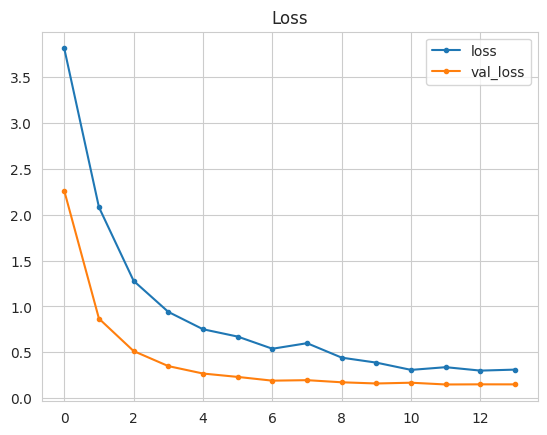

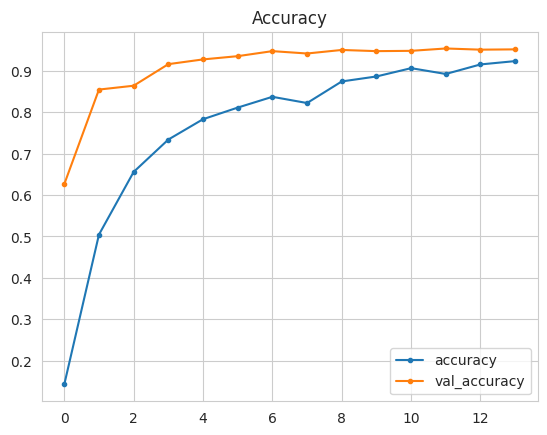

In [27]:
losses = pd.DataFrame(history.history)

sns.set_style("whitegrid")
losses[['loss', 'val_loss']].plot(style='.-')
plt.title("Loss")
plt.savefig(f'{img_path}/small_model_training_losses.jpg',
    bbox_inches='tight', dpi=150)
plt.show()

print("\n")
losses[['accuracy', 'val_accuracy']].plot(style='.-')
plt.title("Accuracy")
plt.savefig(f'{img_path}/small_model_training_acc.jpg',
    bbox_inches='tight', dpi=150)
plt.show()

## Model Evaluation

Load saved model

In [28]:
model = create_tf_model()
model.load_weights('outputs/v1/animal_detector_small_model.weights.h5')

/home/cistudent/.local/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Evaluate model on test set

In [29]:
evaluation = model.evaluate(test_set)

/home/cistudent/.local/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


183/183 ━━━━━━━━━━━━━━━━━━━━ 49s 253ms/step - accuracy: 0.9576 - loss: 0.1420


Save evaluation pickle

In [30]:
joblib.dump(value=evaluation,
    filename=f"outputs/v1/small-data/evaluation.pkl")

print("Test Evaluation:", evaluation)

Test Evaluation: [0.14204871654510498, 0.9576358199119568]


---

# Evaluate Test Set
---

In [31]:
test_loss, test_acc = model.evaluate(test_set, verbose=1)
print(f"\n Test Accuracy: {test_acc:.4f}")
print(f" Test Loss: {test_loss:.4f}")

183/183 ━━━━━━━━━━━━━━━━━━━━ 44s 243ms/step - accuracy: 0.9576 - loss: 0.1420



 Test Accuracy: 0.9576
 Test Loss: 0.1420


### Load true labels

In [32]:
y_true = test_set.classes

Get predicted probablities for test set images

In [33]:
y_pred_probs = model.predict(test_set, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

132/183 ━━━━━━━━━━━━━━━━━━━━ 12s 247ms/step

183/183 ━━━━━━━━━━━━━━━━━━━━ 48s 256ms/step


Map indices back to labels and print classification report

In [34]:
target_names = list(train_set.class_indices.keys())

print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=target_names))


--- Classification Report ---
              precision    recall  f1-score   support

    antelope       0.90      1.00      0.95        44
        bear       0.93      0.98      0.96        44
      beaver       1.00      0.91      0.95        44
         bee       1.00      0.98      0.99        44
       bison       0.82      0.93      0.87        44
   blackbird       0.96      0.98      0.97        44
     buffalo       0.94      0.77      0.85        44
   butterfly       1.00      1.00      1.00        44
       camel       0.93      0.95      0.94        44
         cat       1.00      1.00      1.00        87
     cheetah       1.00      1.00      1.00        44
  chimpanzee       1.00      1.00      1.00        44
  chinchilla       1.00      1.00      1.00        44
         cow       0.98      1.00      0.99        44
        crab       1.00      1.00      1.00        44
   crocodile       1.00      0.86      0.93        44
        deer       1.00      0.91      0.95       

### Confusion Matrix

Text(0.5, 1.0, 'Confusion Matrix - Animal Species Classification')

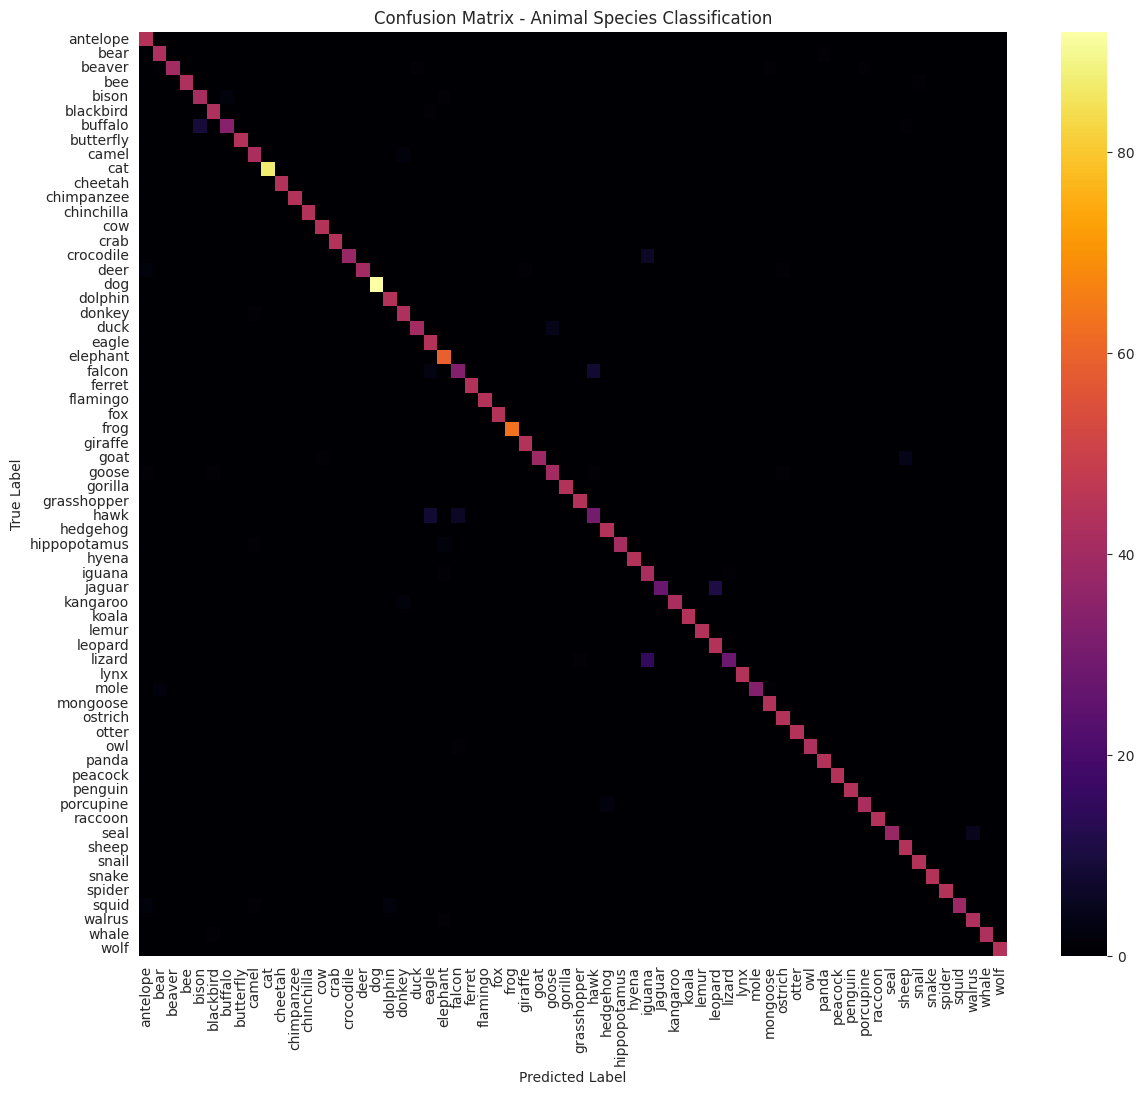

In [35]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=False, cmap="inferno", 
            xticklabels=target_names, 
            yticklabels=target_names, ax=ax)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title("Confusion Matrix - Animal Species Classification")

Save confusion matrix

In [42]:
save_dir = "app_images/small-data"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "confusion_matrix.jpg")
fig.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Confusion matrix saved to {save_path}")

Confusion matrix saved to app_images/small-data/confusion_matrix.jpg


In [37]:
plt.show()

---

# Predict On New Data
---

Load a random image as PIL

Selected species: elephant
Image shape: (128, 128), Image mode: RGB


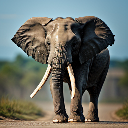

In [38]:
label = random.choice(labels)

# Pick a random image index from that label's folder
pointer = random.randint(0, len(os.listdir(test_path + '/' + label)) - 1)

# Load the image
pil_image = image.load_img(
    test_path + '/' + label + '/' + os.listdir(test_path + '/' + label)[pointer],
    target_size=image_shape[:2],
    color_mode='rgb'
)

print(f"Selected species: {label}")
print(f"Image shape: {pil_image.size}, Image mode: {pil_image.mode}")
pil_image


Convert image to array and prepare for prediction

In [39]:
my_image = image.img_to_array(pil_image)
my_image = np.expand_dims(my_image, axis=0)/255
print(my_image.shape)
print("Image batch shape:", my_image.shape)
print("True label:", label)

(1, 128, 128, 3)
Image batch shape: (1, 128, 128, 3)
True label: elephant


Predict class probabilities

In [40]:
# Get prediction probabilities for all classes
pred_probs = model.predict(my_image)[0]

target_map = {v: k for k, v in train_set.class_indices.items()}

pred_class_index = np.argmax(pred_probs)
pred_class = target_map[pred_class_index]

print("True label:", label)
print("Predicted label:", pred_class)
print("Prediction confidence:", pred_probs[pred_class_index])

# Show top 3 predictions and their probabilities
top_3 = np.argsort(pred_probs)[-3:][::-1]
print("\nTop 3 predictions:")
for i in top_3:
    print(f"{target_map[i]}: {pred_probs[i]:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 954ms/step
True label: elephant
Predicted label: elephant
Prediction confidence: 0.97836626

Top 3 predictions:
elephant: 0.9784
raccoon: 0.0040
ostrich: 0.0035


In [41]:
results_df = pd.DataFrame({
    "filepath": test_set.filepaths,
    "true_label": [target_names[i] for i in y_true],
    "predicted_label": [target_names[i] for i in y_pred]
})

results_df.to_csv("inputs/datasets/animal_predictions.csv", index=False)

results_df["image"] = test_set.filenames